In [9]:
import pandas as pd
import joblib


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


In [10]:
from pathlib import Path

BASE_DIR = Path.cwd().parent   # se estiveres em notebooks/
DATA_DIR = BASE_DIR / "data"
MODELS_DIR = BASE_DIR / "models"

In [11]:
df = pd.read_csv(DATA_DIR / "train.csv")
df.head()
dt= pd.read_csv(DATA_DIR / "test.csv")


In [13]:

categorical_features = [
    'ChiefComplaint',
    'gender']

numeric_features = [
    'age',
    'PulseRate',
    'RespiratoryRate']

target = 'TriageGrade'
features = categorical_features + numeric_features

df = df[categorical_features + numeric_features + [target]]
df[numeric_features] = df[numeric_features].fillna(df[numeric_features].median())
df[categorical_features] = df[categorical_features].fillna("Unknown")

dt = dt[categorical_features + numeric_features + [target]]
dt[numeric_features] = dt[numeric_features].fillna(dt[numeric_features].median())
dt[categorical_features] = dt[categorical_features].fillna("Unknown")



In [14]:
X_train = df[categorical_features + numeric_features]
y_train = df[target]

X_test = dt[categorical_features + numeric_features]
y_test = dt[target]


In [15]:
print(y_train.value_counts())


TriageGrade
2    52712
3    22322
4    11556
1     6706
5       12
Name: count, dtype: int64


In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)])


In [17]:
modelo_logreg_multi = Pipeline(
    steps=[('preprocessamento', preprocessor),
        ('classificador', LogisticRegression(max_iter=1000))])

modelo_logreg_multi.fit(X_train, y_train)

y_pred_logreg_multi = modelo_logreg_multi.predict(X_test)

print("LOGISTIC REGRESSION — MULTI-VARIÁVEL")
print("Accuracy:", accuracy_score(y_test, y_pred_logreg_multi))
print(classification_report(y_test, y_pred_logreg_multi))


LOGISTIC REGRESSION — MULTI-VARIÁVEL
Accuracy: 0.6802619205182683
              precision    recall  f1-score   support

           1       0.79      0.26      0.39      2063
           2       0.73      0.91      0.81     16219
           3       0.53      0.26      0.35      6869
           4       0.56      0.71      0.62      3556
           5       0.00      0.00      0.00         4

    accuracy                           0.68     28711
   macro avg       0.52      0.43      0.43     28711
weighted avg       0.66      0.68      0.64     28711



C:\Users\biamm\PycharmProjects\ProjetoAI\.venv4\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\biamm\PycharmProjects\ProjetoAI\.venv4\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\biamm\PycharmProjects\ProjetoAI\.venv4\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

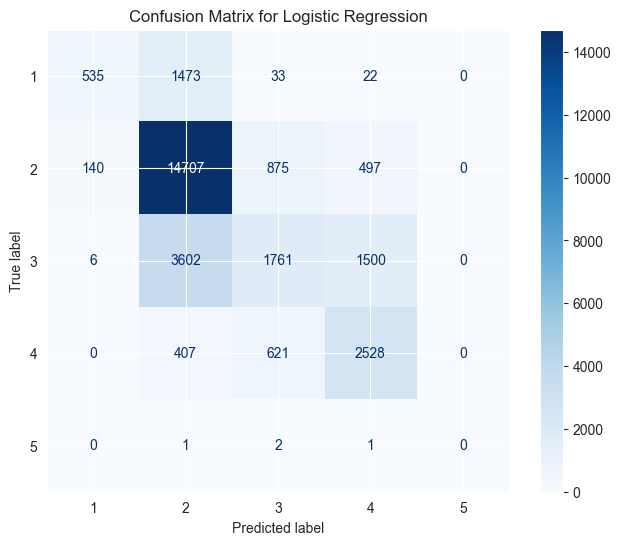

In [18]:
# Plot the Confusion Matrix (Diz quantas pulseiras foram prevista para cada classe)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_logreg_multi, cmap=plt.cm.Blues, ax=ax)
ax.set_title("Confusion Matrix for Logistic Regression")
plt.show()

In [19]:
import os

os.makedirs("models", exist_ok=True)
joblib.dump({
    "model": modelo_logreg_multi,
    "features": features
},"models/modelo_logreg_multi.joblib")



['models/modelo_logreg_multi.joblib']